32.093421936035156
(500, 1000)
max ev: 32.093421936035156, number above threshold: 1
max scrambled ev: 21.287092208862305


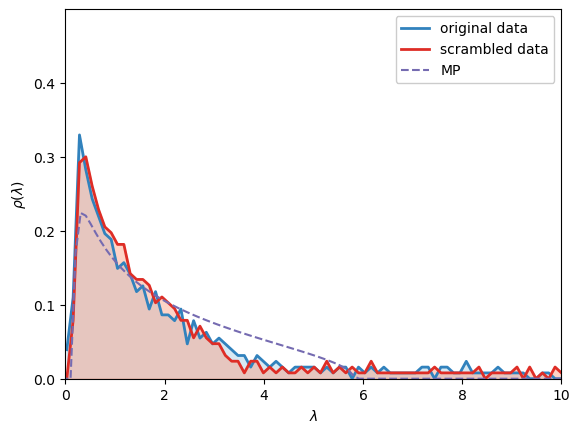

In [17]:
import utils
import importlib
import numpy as np
importlib.reload(utils)
from utils import plot_eig_dist, get_eig_dist, calculate_entropy

# load simulation data
data = np.load("results\\sim5_competitive_J-2.5.npy")

data = data[:,:,-1]
#data = np.log1p(data)
pcs, pcs1 = utils.get_eig_dist(data)
print(np.max(pcs))
print(data.shape)
utils.plot_eig_dist(pcs,pcs1,data.shape[0],10,0.5,80)
print(f'max ev: {np.max(pcs)}, number above threshold: {sum(pcs>np.max(pcs1))}')
print(f'max scrambled ev: {np.max(pcs1)}')

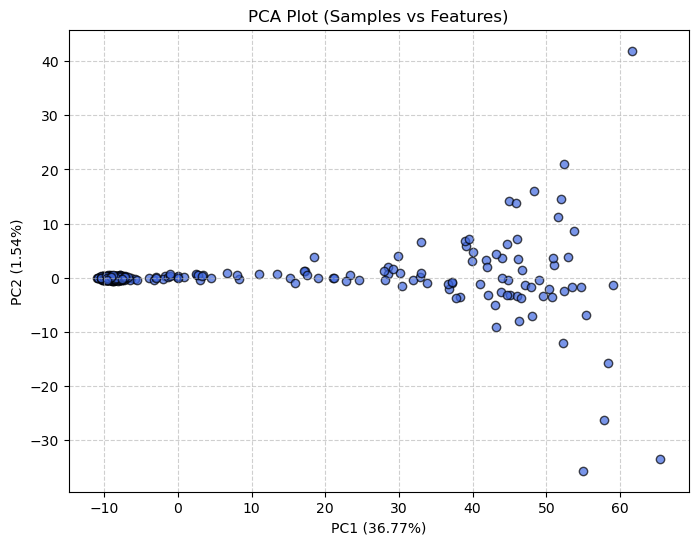

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 2. Standardize the data
# PCA is sensitive to variance; features should be on the same scale.
nan_rows = np.unique(np.where(np.isnan(data))[0])
new_data = np.delete(data, nan_rows, axis=0)
new_data = np.log1p(new_data)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(new_data)

# 3. Apply PCA
# We want the first two principal components for a 2D plot
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data)

# 4. Visualization
plt.figure(figsize=(8, 6))
plt.scatter(pca_results[:, 0], pca_results[:, 1], c='royalblue', edgecolor='k', alpha=0.7)

# Labeling with Variance Explained
# This shows how much "information" each axis actually holds
exp_var = pca.explained_variance_ratio_ * 100
plt.xlabel(f'PC1 ({exp_var[0]:.2f}%)')
plt.ylabel(f'PC2 ({exp_var[1]:.2f}%)')
plt.title('PCA Plot (Samples vs Features)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [240]:
import pandas as pd
import numpy as np
import importlib
import utils
importlib.reload(utils)
from utils import run_de_analysis
# create bulk RNA dataframe
time_points = [0,25,50,75,100,125,150,175]
#time_points = [0,225,250,275,300,325,350,375]
# 1. Setup Metadata
samples = ['t0_1', 't0_2', 't0_3','t1_1', 't1_2', 't1_3','t2_1', 't2_2', 't2_3','t3_1', 't3_2', 't3_3','t4_1', 't4_2', 't4_3','t5_1', 't5_2', 't5_3','t6_1', 't6_2', 't6_3','t7_1', 't7_2', 't7_3']
metadata = pd.DataFrame({
    'condition': ['t0', 't0', 't0','t1', 't1', 't1','t2', 't2', 't2','t3', 't3', 't3','t4', 't4', 't4','t5', 't5', 't5','t6', 't6', 't6','t7', 't7', 't7']
}, index=samples)
# 2. Load data
data1 = np.load("results\\sim3_J-1_rep1.npy")
data2 = np.load("results\\sim3_J-1_rep2.npy")
data3 = np.load("results\\sim3_J-1_rep3.npy")
combined_data = [data1,data2,data3]
# 3. Create count matrix
gene_num = data1.shape[1]
print(f"number of genes: {gene_num}")
gene_ids = [f'gene_{i}' for i in range(gene_num)]
count_matrix = pd.DataFrame(index=gene_ids, columns=samples)
for sample in samples:
    time = int(sample.split('_')[0][1])
    rep = int(sample.split('_')[1])
    print('time:', time, 'rep:', rep)
    counts = np.sum(combined_data[rep-1][:,:,time_points[time]],axis=0)
    count_matrix[sample] = counts
# 4. Run differential expression analysis
de_data = []
for i in range(len(time_points)-1):
    de_data.append(run_de_analysis(count_matrix,metadata, test_time=i+1))

number of genes: 1000
time: 0 rep: 1
time: 0 rep: 2
time: 0 rep: 3
time: 1 rep: 1
time: 1 rep: 2
time: 1 rep: 3
time: 2 rep: 1
time: 2 rep: 2
time: 2 rep: 3
time: 3 rep: 1
time: 3 rep: 2
time: 3 rep: 3
time: 4 rep: 1
time: 4 rep: 2
time: 4 rep: 3
time: 5 rep: 1
time: 5 rep: 2
time: 5 rep: 3
time: 6 rep: 1
time: 6 rep: 2
time: 6 rep: 3
time: 7 rep: 1
time: 7 rep: 2
time: 7 rep: 3


significant genes in dataset 0: 94
significant genes in dataset 1: 407
significant genes in dataset 2: 501
significant genes in dataset 3: 552
significant genes in dataset 4: 608
significant genes in dataset 5: 626
significant genes in dataset 6: 665
common genes: 54


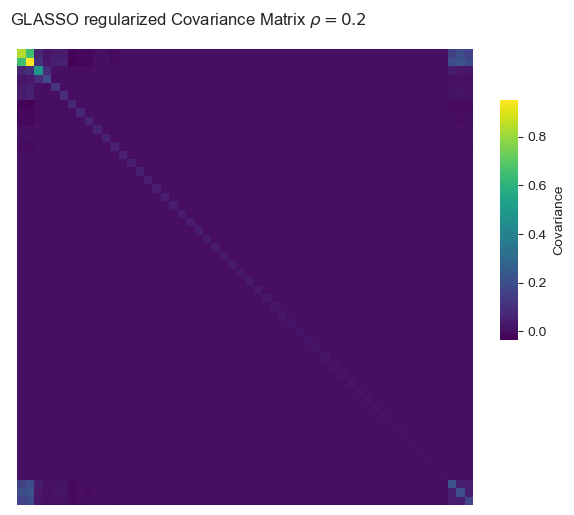

entropy calculated with lambda=0.2, p-adj<0.35: -183.58090553598484


In [245]:
import utils
importlib.reload(utils)
from utils import calculate_entropy
# find significant genes in all datasets
threshold = 0.35
reg_param=0.2
for i in range(len(de_data)):
    ind =np.logical_and(de_data[i]['padj']<threshold, de_data[i]['log2FoldChange']>-10)
    gene_list = de_data[i].loc[ind].index.to_list()
    print(f"significant genes in dataset {i}: {len(gene_list)}")
    if i>0:
        gene_list = list(set(gene_list) & set(previous_gene_list))
    previous_gene_list = gene_list
print(f'common genes: {len(gene_list)}')

#create DE_matrix
DE_matrix = np.zeros((len(de_data), len(gene_list)))
for i in range(len(de_data)):
    DE_matrix[i,:] = de_data[i].loc[gene_list,'log2FoldChange'].values
print(f'entropy calculated with lambda={reg_param}, p-adj<{threshold}: {calculate_entropy(DE_matrix,reg_param)}')

Text(0, 0.5, 'time-points')

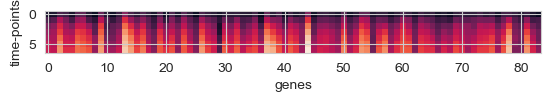

In [157]:
import matplotlib.pyplot as plt
plt.imshow(DE_matrix)
plt.xlabel('genes')
plt.ylabel('time-points')

SlogdetResult(sign=np.float64(1.0), logabsdet=np.float64(-179.02023449250404))


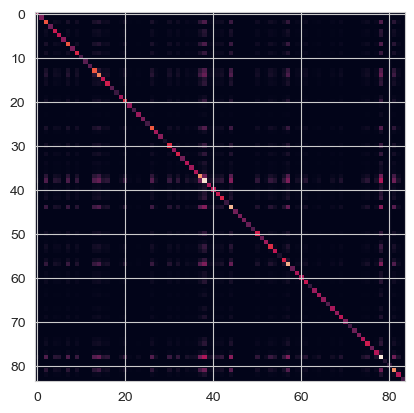

In [167]:
import sklearn
reg_param=0.2
model = sklearn.covariance.GraphicalLasso(alpha=reg_param,max_iter=1000, tol=0.001)
model.fit(DE_matrix)
plt.imshow(model.covariance_)
print(np.linalg.slogdet(model.covariance_))

C:\Users\owner\Documents\Projects\dysregulation_simulations\utils.py:212: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\owner\Documents\Projects\dysregulation_simulations\utils.py:213: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.


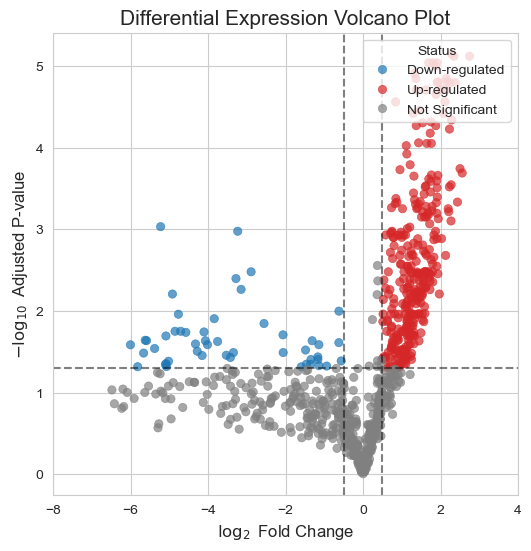

In [149]:
# plot volcano plot
import utils
importlib.reload(utils)
utils.plot_volcano(de_data[6],0.5,0.05)

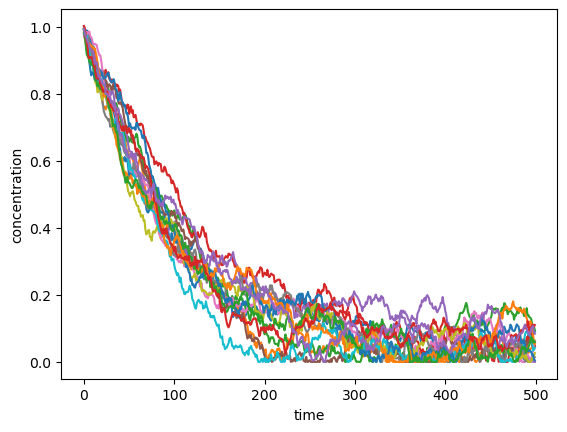

In [26]:
import matplotlib.pyplot as plt
data = np.load("results\\sim5_competitive_J-0.npy")
for i in range(0,data.shape[0],100):
    for j in range(0,data.shape[1],100):
        plt.plot(data[i,j,:])
plt.xlabel('time')
plt.ylabel('concentration')
plt.show()
